# Baseline modeling

So sánh SVR, RandomForest và XGBoost trên toàn bộ feature sau tiền xử lý. CV chỉ dùng trên tập train; tập test chỉ được dùng ở bước đánh giá cuối.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from src.evaluate import evaluate_model
from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data/processed/X_train.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data/processed'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
N_SPLITS = 5

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze('columns')
feature_names = pd.read_csv(DATA_DIR / 'feature_names.csv')['feature'].tolist()

assert list(X_train.columns) == feature_names
assert list(X_test.columns) == feature_names
assert y_train.name == 'log_SalePrice'
assert y_test.name == 'log_SalePrice'
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1166, 265) | Test: (292, 265)


In [2]:
models = {
    'SVR': SVR(C=10.0, epsilon=0.01, kernel='rbf'),
    'RandomForest': RandomForestRegressor(
        n_estimators=400,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}
print('Models:', ', '.join(models))

Models: SVR, RandomForest, XGBoost


In [3]:
evaluated = [
    evaluate_model(
        'baseline',
        name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        N_SPLITS,
        RANDOM_STATE,
    )
    for name, model in models.items()
]
fitted_models = {result['model']: result.pop('_fitted_model') for result in evaluated}
results = pd.DataFrame(evaluated).sort_values('cv_log_rmse').reset_index(drop=True)
display(results.round(4))
results.to_csv(DATA_DIR / 'baseline_results.csv', index=False)
best_name = results.loc[0, 'model']
joblib.dump(fitted_models[best_name], MODEL_DIR / 'baseline_best_model.pkl')
print('Best baseline theo CV log RMSE:', best_name)

,technique,model,cv_log_rmse,cv_log_mae,cv_log_r2,cv_original_rmse,cv_original_mae,cv_original_r2,test_log_rmse,test_log_mae,test_log_r2,test_original_rmse,test_original_mae,test_original_r2,n_features,cv_seconds,train_seconds
0,baseline,XGBoost,0.1161,0.0793,0.9135,23382.9935,14303.7137,0.9144,0.1167,0.0810,0.9192,18836.1615,13789.7454,0.9358,265,3.3097,0.6654
1,baseline,RandomForest,0.1330,0.0919,0.8868,26599.5451,16563.0811,0.8893,0.1416,0.0951,0.8811,23085.8974,16157.5014,0.9035,265,3.7976,0.8036
2,baseline,SVR,0.1389,0.0918,0.8753,30397.6519,16635.6502,0.8503,0.1419,0.0906,0.8806,22065.4098,15595.0506,0.9119,265,0.6510,0.1547


Best baseline theo CV log RMSE: XGBoost


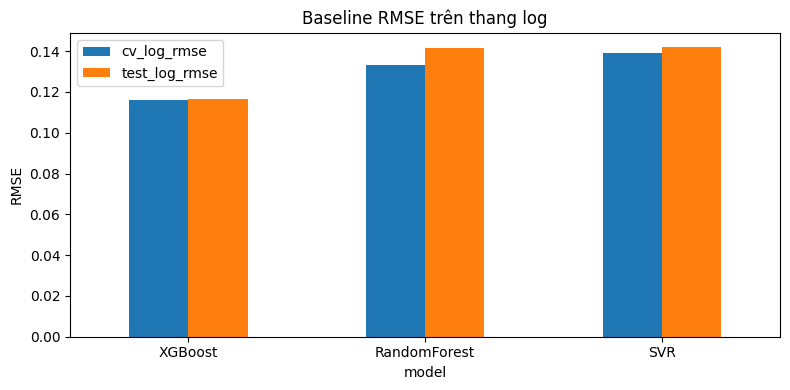

Đã lưu kết quả baseline và model tốt nhất.


In [4]:
plot_data = results.set_index('model')[['cv_log_rmse', 'test_log_rmse']]
plot_data.plot(kind='bar', figsize=(8, 4), title='Baseline RMSE trên thang log')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

for output_path in [
    DATA_DIR / 'baseline_results.csv',
    MODEL_DIR / 'baseline_best_model.pkl',
]:
    assert output_path.exists(), output_path
print('Đã lưu kết quả baseline và model tốt nhất.')